In [2]:
import pandas as pd
from dotenv import load_dotenv
load_dotenv()

from app.services.db_service import DbService

sql_db_service = DbService()

await sql_db_service.init_pool()

In [12]:
port, err = await sql_db_service.get_port_by_locode("RULED")
fuels, err = await sql_db_service.get_available_fuels()

In [13]:
prices_timeserias = {}
for fuel in fuels:
    port_fuel_price, err = await sql_db_service.get_port_fuel_cost_timeseria2(port.locode, fuel.name)
    if err:
        continue
    if port_fuel_price is None:
        continue

    if fuel.name in prices_timeserias.keys():
        prices_timeserias[fuel.name].append(port_fuel_price)
    prices_timeserias[fuel.name] = port_fuel_price


In [14]:
df_final = (pd.concat([
    pd.DataFrame([{ "date": r.date, fuel: r.value } for r in recs])
    for fuel, recs in prices_timeserias.items()
], axis=0)
 .groupby("date").first()
 #.reset_index()
 .sort_index())
df_final

,380cSt HSFO,MGO LS,ULS FO,VLS FO
date,,,,
2025-12-12,355.0,740.0,690.0,490.0
2025-12-15,340.0,740.0,690.0,490.0
2025-12-16,340.0,740.0,690.0,490.0


In [10]:
df.index

Index([2025-12-12, 2025-12-15, 2025-12-16], dtype='object', name='date')

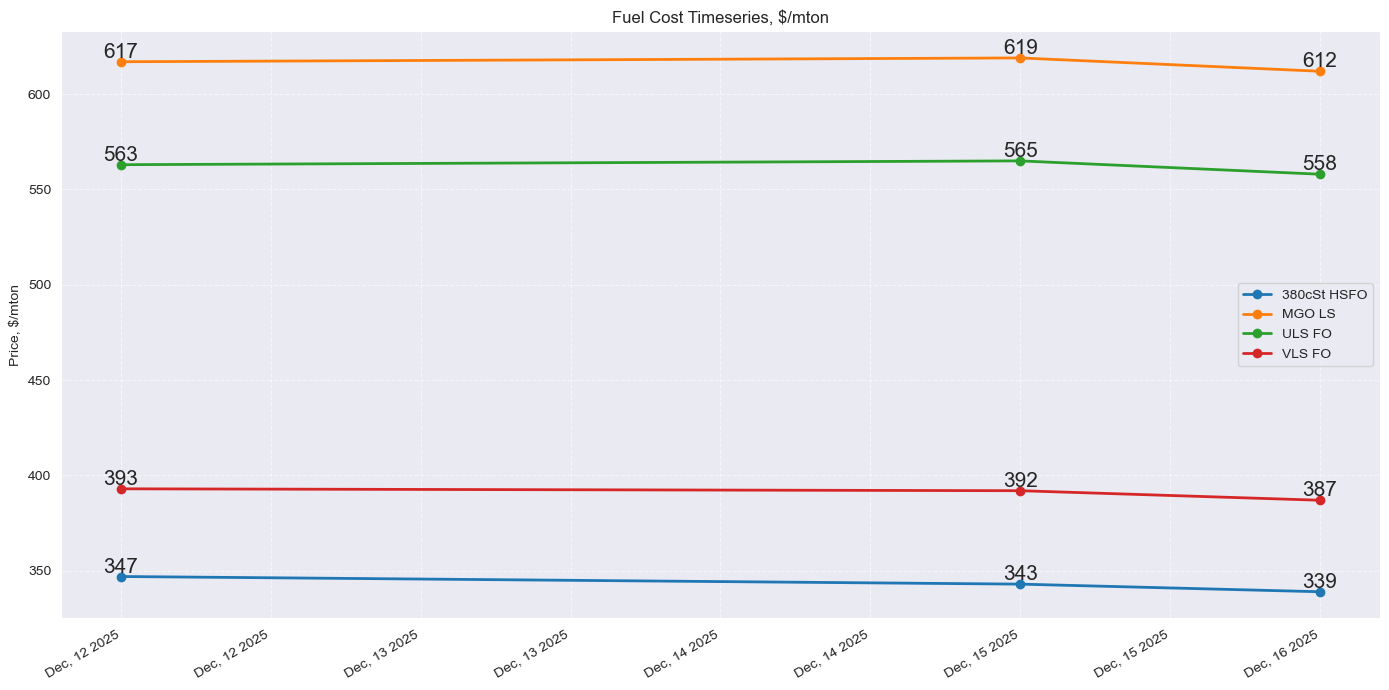

,max,avg,min,latest,std_dev
380cSt HSFO,347.0,343.000000,339.0,339.0,4.000000
MGO LS,619.0,616.000000,612.0,612.0,3.605551
ULS FO,565.0,562.000000,558.0,558.0,3.605551
VLS FO,393.0,390.666667,387.0,387.0,3.214550


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# use date as index
df = df_final

# ---- Plot ----
plt.figure(figsize=(14, 7))

for fuel in df.columns:
    plt.plot(df.index, df[fuel], marker="o", linewidth=2)
    for x, y in zip(df.index, df[fuel]):
        if pd.notna(y):
            plt.text(x, y, f"{y:.0f}", fontsize=15, ha="center", va="bottom")
date_format = DateFormatter("%b, %d %Y")   # Example: December, 20 2025
plt.gca().xaxis.set_major_formatter(date_format)

plt.gcf().autofmt_xdate()  # rotates and aligns labels automatically
plt.grid(True, linestyle="--", alpha=0.6)
#plt.xlabel("Date")
plt.ylabel("Price, $/mton")
plt.title("Fuel Cost Timeseries, $/mton")
plt.legend(df.columns)
plt.tight_layout()
plt.savefig("lines.png")
plt.show()


# ---- Stats ----
stats = pd.DataFrame({
    fuel: {
        "max": df[fuel].max(),
        "avg": df[fuel].mean(),
        "min": df[fuel].min(),
        "latest": df[fuel].dropna().iloc[-1] if df[fuel].notna().any() else None
    }
    for fuel in df.columns
}).T

# ---- Extra useful metric: volatility (std deviation) ----
stats["std_dev"] = [df[fuel].std() for fuel in df.columns]

stats


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.dates import DateFormatter

# --- Prepare data ---
df.index = pd.to_datetime(df.index)
full_idx = pd.date_range(df.index.min(), df.index.max(), freq='D')
df_full = df.reindex(full_idx)
df_full.index.name = 'date'
df_full.index = df_full.index.date  # remove time

# --- Plot setup ---
plt.figure(figsize=(16, 8))

x = np.arange(len(df_full.index))
num_fuels = len(df_full.columns)
# adaptive bar width based on number of fuels
bar_width = min(0.8 / num_fuels, 0.3)  # max width per group = 0.8

# Choose a color palette
colors = plt.get_cmap("tab10").colors  # 10 distinct colors
fuel_colors = {fuel: colors[i % len(colors)] for i, fuel in enumerate(df_full.columns)}

# --- Plot bars ---
for i, fuel in enumerate(df_full.columns):
    for j, value in enumerate(df_full[fuel]):
        if not np.isnan(value):
            bar = plt.bar(
                x[j] + i * bar_width,
                value,
                width=bar_width,
                color=fuel_colors[fuel],
                label=fuel if j == 0 else "",
                alpha=0.7
            )
            plt.text(
                x[j] + i * bar_width,
                value,
                f'{int(value)}',
                ha='center', va='bottom', fontsize=10
            )

# --- Date formatting ---
date_format = DateFormatter("%b %d %Y")  # Dec 25 2025
plt.gca().xaxis.set_major_formatter(date_format)
plt.gcf().autofmt_xdate(rotation=45)

# Center x-ticks under bar groups
plt.xticks(
    x + bar_width * (num_fuels - 1) / 2,
    [d.strftime("%b %d %Y") for d in df_full.index],
    rotation=45,
    ha='right'
)
# --- Labels & Grid ---
plt.ylabel("Price, $/mton")
plt.title("Fuel Cost Timeseries — Adaptive Bar Width with Gaps")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
min_price = df_full.min().min()
plt.ylim(bottom=min_price * 0.8)
# --- Legend with correct colors ---
handles = [plt.Rectangle((0,0),1,1,color=fuel_colors[fuel]) for fuel in df_full.columns]
plt.legend(handles, df_full.columns, loc='lower right', bbox_to_anchor=(1, 0))
plt.tight_layout()
plt.savefig("bars_adaptive_colors.jpg", dpi=300)
plt.show()


In [ ]:
df_roll = df.rolling(3, min_periods=1).mean()

df_roll.plot(figsize=(14, 7), linewidth=3)
plt.title("Fuel Prices (3-day Rolling Average)")
plt.grid(True, linestyle="--", alpha=0.5)

In [ ]:
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.heatmap(df.T, cmap="coolwarm", annot=True, fmt=".0f", square=True )
plt.title("Fuel Price Heatmap")
plt.xlabel("Date")
plt.ylabel("Fuel")
plt.tight_layout()
plt.savefig("fig.png")

In [ ]:
df_diff = df.diff()

df_diff.plot(figsize=(14, 7), marker="o")
plt.title("Daily Price Change")
plt.grid(True, linestyle="--", alpha=0.5)

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="viridis")
plt.title("Fuel Price Correlation")
plt.tight_layout()


In [ ]:
insights = {}
for fuel in df.columns:
    s = df[fuel].dropna()
    insights[fuel] = {
        "max_value": s.max(),
        "min_value": s.min(),
        "avg_value": s.mean(),
        "volatility": s.std(),
        "num_days": len(s),
        "latest": s.iloc[-1],
        "change_last_week": s.iloc[-1] - s.iloc[-7] if len(s) >= 7 else None
    }

insights
